# Publication Screening on Single Case Design Research

---

In [1]:
from datetime import datetime
date = datetime.now()
formatted_date = date.strftime("%B %d, %Y")
print(formatted_date)

May 17, 2025


## 0. Configuring the System Environment

In [2]:
# Check GPU memory
!nvidia-smi

Sat May 17 12:52:26 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             68W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
# Check system RAM
!free -h

               total        used        free      shared  buff/cache   available
Mem:            83Gi       976Mi        73Gi       3.0Mi       8.6Gi        81Gi
Swap:             0B          0B          0B


## 1. Setting Up the Computing Environment
##### Install and load Python libraries.

In [4]:
# Access files and folders within the Google Drive
from google.colab import drive
drive.mount('/content/drive')

from google.colab import userdata
userdata.get('HF_TOKEN')

# Set up the current working directory within the Google Drive
%cd /content/drive/My\ Drive/Colab\ Notebooks/LLM/sped_biblio/screening_single_case

# Set up the current working directory within G Drive (Desktop)
# %cd "G:/My Drive/Colab Notebooks/LLM/sped_biblio/screening_single_case"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/Colab Notebooks/LLM/sped_biblio/screening_single_case


In [5]:
# !pip install -q condacolab
# import condacolab
# condacolab.install()
# !conda env create -f python-venv-environment.yml

In [6]:
# "conda activate python-venv" in the terminal
# !pip install -r requirements.txt

In [7]:
# Import Python libraries
import pandas as pd
import spacy
import torch
from torch.optim import AdamW
import torch.nn as nn
from torch.utils.data.sampler import RandomSampler, SequentialSampler
from transformers import BertTokenizer
from sources.preprocess import split_data, preprocess_dataset, create_dataloader
from sources.model import PubMLP, train_evaluate_model, predict_model
from sources.plot import plot_results
import warnings

## 2. Screening Studies on Single Case Design Research

##### Prepare data for training, validation, and testing.


In [8]:
warnings.filterwarnings('ignore', category=FutureWarning)

# Load data
labeled_data = pd.read_excel("files/labeled_data.xlsx")

# Select relevant columns
labeled_df = labeled_data[['UT', 'single_case', 'technology_use', 'SO', 'PY', 'AF', 'TI', 'AB', 'DE']]
labeled_df = labeled_df.copy()

missing_values = labeled_df.isnull().sum()
print(missing_values)

df = labeled_df.copy()

# Convert to numeric data
df["PY"] = pd.to_numeric(df["PY"], errors='coerce')

# Replace missing values
df.dropna(subset=["PY"], inplace=True)

train_df, validation_df, test_df = split_data(df)

print(f"Training data number: {len(train_df)}")
print(f"Validation data number: {len(validation_df)}")
print(f"Testing data number: {len(test_df)}")

UT                  0
single_case         0
technology_use      0
SO                  0
PY                  0
AF                  0
TI                  0
AB                  0
DE                269
dtype: int64
Training data number: 1264
Validation data number: 158
Testing data number: 158


##### Preprocess data and convert to dataloaders.


In [9]:
warnings.filterwarnings('ignore', category=FutureWarning)

# Configure reproducible environments
random_seed = 2025
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", do_lower_case=True)

# Define columns for preprocessing
col_lists = {
    "text_cols": ['AF', 'TI', 'AB', 'DE'],
    "categorical_cols": ['SO'],
    "numeric_cols": ['PY'],
    "label_col": ['single_case']
}

# Define transformation options for numeric data
numeric_transform = {
    'PY': 'min'
}

label_col = col_lists['label_col'][0]

train_df[label_col] = train_df[label_col].map({'Yes': 1, 'No': 0})
validation_df[label_col] = validation_df[label_col].map({'Yes': 1, 'No': 0})
test_df[label_col] = test_df[label_col].map({'Yes': 1, 'No': 0})

# Preprocess and create dataloaders
train_dataset = preprocess_dataset(train_df, tokenizer, device, col_lists, numeric_transform)
train_dataloader = create_dataloader(train_dataset, RandomSampler, batch_size=8)

validation_dataset = preprocess_dataset(validation_df, tokenizer, device, col_lists, numeric_transform)
validation_dataloader = create_dataloader(validation_dataset, SequentialSampler, batch_size=8)

test_dataset = preprocess_dataset(test_df, tokenizer, device, col_lists, numeric_transform)
test_dataloader = create_dataloader(test_dataset, SequentialSampler, batch_size=8)

Preprocessed data saved to preprocessed_data_single_case_05172025_075249.xlsx
Preprocessed data saved to preprocessed_data_single_case_05172025_075250.xlsx
Preprocessed data saved to preprocessed_data_single_case_05172025_075250.xlsx


##### Train the model and perform validation.

In [10]:
# Initialize the PubMLP model which is based on the BERT model
model = PubMLP(categorical_cols_num=1,
               numeric_cols_num=1,
               mlp_hidden_size=16,
               output_size=1,
               dropout_rate=0.2).to(device)

# Number of training epochs
epochs = 3

# Define loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optim = AdamW(model.parameters(), lr=1e-5, eps = 1e-8)

# Evaluate PubMLP model
train_losses, validation_losses, train_accuracies, validation_accuracies, test_accuracy, best_val_loss, best_model_state = train_evaluate_model(model, train_dataloader, validation_dataloader, test_dataloader, optim, criterion, device, epochs)

torch.save(best_model_state, f"best_model_state_{label_col}.pth")

Epoch: 0001/0003 | Training Loss: 0.549 | Validation Loss: 0.423
Training Accuracy: 83.465% | Validation Accuracy: 82.278%
Time elapsed: 0.59 min
Epoch: 0002/0003 | Training Loss: 0.397 | Validation Loss: 0.315
Training Accuracy: 95.095% | Validation Accuracy: 95.570%
Time elapsed: 1.18 min
Epoch: 0003/0003 | Training Loss: 0.321 | Validation Loss: 0.262
Training Accuracy: 96.519% | Validation Accuracy: 95.570%
Time elapsed: 1.77 min
Test Accuracy: 96.203%


##### Plot shows training losses, validation losses, training accuracies, validation accuracies, test accuracy, and the best validation loss over time.

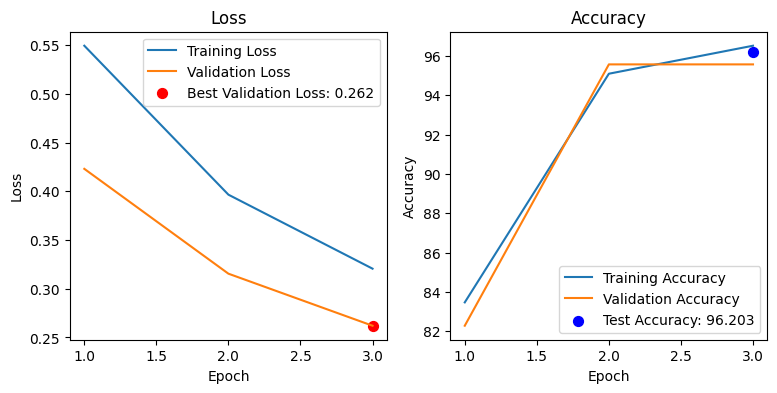

In [11]:
plot_results(train_losses, validation_losses, train_accuracies, validation_accuracies, test_accuracy, best_val_loss)

##### Filter rows where "single_case" is NA (not labeled).

In [12]:
# Ignore warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='huggingface_hub')
warnings.filterwarnings('ignore', message="^.*\[W111\].*$")

# Configure reproducible environments
random_seed = 2025
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

labeled_data = pd.read_excel("files/labeled_data.xlsx")
init_all_data = pd.read_csv("files/init_all_data.csv")

missing_uts = set(labeled_data['UT']) - set(init_all_data['UT'])
if missing_uts:
    print(f"Removing {len(missing_uts)} rows from labeled_data; these UTs are not in init_all_data:\n{missing_uts}")
    labeled_data = labeled_data[labeled_data['UT'].isin(init_all_data['UT'])]

init_all_data = pd.merge(init_all_data, labeled_data, on="UT", how="left", suffixes=("", "_y"))

init_all_data = init_all_data.loc[:, ~init_all_data.columns.str.endswith("_y")]

init_all_data.columns = init_all_data.columns.str.replace("_x$", "", regex=True)

unlabeled_data = init_all_data[pd.isna(init_all_data["single_case"])]

unlabeled_file_name = f"files/unlabeled_data.xlsx"
unlabeled_data.to_excel(unlabeled_file_name, index=False)
print(f"Data saved to {unlabeled_file_name}")

unlabeled_data = pd.read_excel(unlabeled_file_name)

Data saved to files/unlabeled_data.xlsx


In [13]:
# Select relevant columns
unlabeled_df = unlabeled_data[['UT', 'single_case', 'technology_use', 'SO', 'PY', 'AF', 'TI', 'AB', 'DE']]
unlabeled_df = unlabeled_df.copy()

# Convert PY (publication year) to numeric format
unlabeled_df["PY"] = pd.to_numeric(unlabeled_df["PY"], errors="coerce")

# Check columns with text data
# print(unlabeled_df.describe(include=object))

# Check columns with numeric data
# print(unlabeled_df.describe())

missing_values = unlabeled_df.isnull().sum()
print(missing_values)

UT                   0
single_case       4349
technology_use    4349
SO                   0
PY                   0
AF                   0
TI                   0
AB                 129
DE                 912
dtype: int64


##### Load the BERT tokenizer.

In [14]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", do_lower_case=True)

##### Preprocess and create dataloaders.

In [15]:
# Define column lists
col_lists = {
    "text_cols": ['AF', 'TI', 'AB', 'DE'],
    "categorical_cols": ['SO'],
    "numeric_cols": ['PY'],
    "label_col": ['single_case']
}

# Define transformation options for numeric data
numeric_transform = {
    'PY': 'min'
}

label_col = col_lists['label_col'][0]

unlabeled_df[label_col] = unlabeled_df[label_col].map({'Yes': 1, 'No': 0})

# Preprocess and create dataloaders
unlabeled_dataset = preprocess_dataset(unlabeled_df, tokenizer, device, col_lists, numeric_transform)

unlabeled_dataloader = create_dataloader(unlabeled_dataset, SequentialSampler, batch_size=8)

Preprocessed data saved to preprocessed_data_single_case_05172025_075523.xlsx


##### Load and initialize the PubMLP model.

In [16]:
# Initialize the PubMLP model which is based on the BERT model
model = PubMLP(categorical_cols_num=1,
               numeric_cols_num=1,
               mlp_hidden_size=16,
               output_size=1,
               dropout_rate=0.2).to(device)

best_model_state = f"best_model_state_{label_col}.pth"
model.load_state_dict(torch.load(best_model_state))

<All keys matched successfully>

##### Predict each publication.

In [17]:
predictions = predict_model(model, unlabeled_dataloader, device)

best_predictions = {}
best_predictions[label_col] = predictions

predictions_data = pd.DataFrame({
    label_col: ['Yes' if p == 1 else 'No' for p in best_predictions[label_col]]
})

if len(predictions_data) == len(unlabeled_df):
    unlabeled_df[label_col] = predictions_data[label_col]
    predicted_data = unlabeled_df.rename(columns={label_col: label_col})
else:
    print("The number of rows in predictions_df and unlabeled_df does not match.")

predicted_file = f"files/predicted_data_{label_col}.xlsx"
predicted_data.to_excel(predicted_file, index=False)
print(f"Data saved to {predicted_file}")

screened_pubs = predicted_data[label_col].value_counts().get('Yes', 0)
print(f"Number of 'Yes' predictions for {label_col}: {screened_pubs}")

Data saved to files/predicted_data_single_case.xlsx
Number of 'Yes' predictions for single_case: 2380


In [18]:
all_data = pd.merge(predicted_data, init_all_data, on="UT", how="left", suffixes=("", "_y"))
all_data = all_data.loc[:, ~all_data.columns.str.endswith("_y")]
all_data.columns = all_data.columns.str.replace("_x$", "", regex=True)

all_data_file = f"files/all_data_{label_col}.xlsx"
all_data.to_excel(all_data_file, index=False)
print(f"Data saved to {all_data_file}")

Data saved to files/all_data_single_case.xlsx


In [20]:
from nbconvert import HTMLExporter
import nbformat

notebook_path = 'index.ipynb'
html_exporter = HTMLExporter()

with open(notebook_path, 'r', encoding='utf-8') as nb_file:
    notebook_content = nb_file.read()
    notebook = nbformat.reads(notebook_content, as_version=4)

if 'widgets' in notebook.metadata and 'application/vnd.jupyter.widget-state+json' in notebook.metadata['widgets']:
    if 'state' not in notebook.metadata['widgets']['application/vnd.jupyter.widget-state+json']:
        notebook.metadata['widgets']['application/vnd.jupyter.widget-state+json']['state'] = {}

html_output, _ = html_exporter.from_notebook_node(notebook)

with open('index.html', 'w', encoding='utf-8') as html_file:
    html_file.write(html_output)